In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import networkx as nx
import scipy.sparse.linalg as spla
import random

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm

from k_regular_graph_generator import generate_multiple_k_regular_graphs
from ql_bit_generator import generate_quantum_like_bit, visualize_ql_bit
from eigenvalue_analysis import *
from bell_state_generation import *
from cartesian_prod_complete import *

np.set_printoptions(
    threshold=15000,      # Total number of array elements to display
    linewidth=200,        # Number of characters per line (increase for longer rows)
    suppress=True,        # Suppress scientific notation for small numbers
    precision=3,          # Number of digits of precision for floating point
    edgeitems=10         # Number of items at beginning and end of each dimension
)

In [3]:
coupled_matrix_a, info = generate_quantum_like_bit(10, 8, 10, 8, 1)

P_cart = nx.cartesian_product(nx.from_numpy_array(coupled_matrix_a), nx.from_numpy_array(coupled_matrix_a))
P_1_cart = nx.cartesian_product(P_cart, nx.from_numpy_array(coupled_matrix_a))
# P_2_cart = nx.cartesian_product(P_1_cart, nx.from_numpy_array(coupled_matrix_a))

P = nx.cartesian_product(nx.from_numpy_array(coupled_matrix_a), nx.complete_graph(2))
P_1 = nx.cartesian_product(P, nx.complete_graph(2))
# P_2 = nx.cartesian_product(P_1, nx.complete_graph(2))

In [4]:
# color_palette = [
#     "#C76526",  # Red-Orange
#     "#EA3368",  # Red-Pink
#     "#E63380",  # Hot Pink
#     "#EA33AD",  # Pink-Magenta
#     "#D631EC",  # Magenta
#     "#8761CD",  # Purple
#     "#85559B",  # Purple
#     "#9B80BD",  # Light Purple
#     "#315E7F",  # Dark Blue
#     "#2A4374",  # Navy Blue
#     "#3070AD",  # Blue
#     "#67ABE0",  # Light Blue
#     "#B6D7E3",  # Very Light Blue
#     "#4CA889",  # Teal
#     "#67C5AC",  # Teal-Cyan
#     "#78AA61",  # Green
#     "#89FC6E",  # Bright Green
#     "#F7CD46",  # Yellow
#     "#E5D98E",  # Light Yellow
#     "#DCA237",  # Gold/Orange
#     "#C07DA5",  # Mauve/Rose
#     "#4A1A2D",  # Dark Brown/Burgundy
#     "#808080",  # Gray (neutral)
# ]

# Best for colorblindness (high contrast, different hues)
two_color_sets = [
    # ["#3070AD", "#DCA237"],      # Blue + Gold (excellent)
    # ["#4CA889", "#EA3368"],      # Teal + Red-Pink (excellent)
    # ["#F7CD46", "#315E7F"],      # Yellow + Dark Blue (excellent)
    # ["#84CC63", "#D631EC"],      # Green + Magenta (good)
    # ["#67ABE0", "#C76526"],      # Light Blue + Red-Orange (good)
    # ['#315E7F', '#EA3368'],
    # ['#E63380', '#85559B'], 
    # ['#E63380', '#3070AD'], 
    ["#7A339C", "#EAAC38"], 
    # ['#8761CD', '#808080'], 
    # ["#FF1CB3", "#68ED2A"], 
    # ['#85559B', '#EA3368'], 
    # ['#8761CD', '#808080'],
    # ["#6AB1F8", "#EF9383FF"],
    # ["#6AB1F8", "#F2B2DE"],
    ["#EA8884", "#77B1F6"]
]

# Best for colorblindness (well-separated on color wheel)
three_color_sets = [
    ["#3070AD", "#F7CD46", "#EA3368"],     # Blue + Yellow + Red-Pink (excellent)
    ["#4CA889", "#DCA237", "#8761CD"],     # Teal + Gold + Purple (excellent)
    ["#315E7F", "#78AA61", "#C76526"],     # Dark Blue + Green + Red-Orange (good)
    ["#67ABE0", "#E5D98E", "#E63380"],     # Light Blue + Light Yellow + Hot Pink (good)
    ["#2A4374", "#89FC6E", "#EA33AD"],     # Navy + Bright Green + Pink-Magenta (good)
]

# Best for colorblindness (maximum separation)
four_color_sets = [
    # ["#3070AD", "#F7CD46", "#EA3368", "#4CA889"],       # Blue + Yellow + Red + Teal (excellent)
    # ["#315E7F", "#DCA237", "#78AA61", "#D631EC"],       # Dark Blue + Gold + Green + Magenta (excellent)
    # ["#67ABE0", "#E5D98E", "#C76526", "#85559B"],       # Light Blue + Light Yellow + Red-Orange + Purple (good)
    # ["#2A4374", "#89FC6E", "#E63380", "#67C5AC"],       # Navy + Bright Green + Hot Pink + Teal-Cyan (good)
    # ["#808080", "#3070AD", "#DCA237", "#EA3368"],       # Gray + Blue + Gold + Red-Pink (good, with neutral)
    ["#7A339C", "#EAAC38", "#EA8884", "#77B1F6"]
]

----------------
----------------

## Cartesian Product vs Equitable Partition Quotient Graph

In [87]:
coupled_matrix_a, info = generate_quantum_like_bit(3, 2, 3, 2, 1)
coupled_matrix_b, info = generate_quantum_like_bit(3, 2, 3, 2, 1)
r_a = coupled_matrix_a
r_b = coupled_matrix_b

In [6]:
# r_cb_dim = 2 * len(r_a)
# r_cb = np.zeros([r_cb_dim, r_cb_dim])

# # Define common dimensions
# q = r_cb_dim // 4
# h_a = len(r_a) // 2

# # Extract quadrants from r_a and r_b
# a_1 = r_a[:h_a, :h_a]  # top-left
# c_a = r_a[:h_a, h_a:]  # top-right
# c_a_T = r_a[h_a:, :h_a]  # bottom-left
# a_2 = r_a[h_a:, h_a:]  # bottom-right

# b_1 = r_b[:h_a, :h_a]  # top-left
# c_b = r_b[:h_a, h_a:]  # top-right
# c_b_T = r_b[h_a:, :h_a]  # bottom-left
# b_2 = r_b[h_a:, h_a:]  # bottom-right

# # Diagonal blocks 
# r_cb[0:q, 0:q] = a_1 + b_1
# r_cb[q:2*q, q:2*q] = a_1 + b_2
# r_cb[2*q:3*q, 2*q:3*q] = a_2 + b_1
# r_cb[3*q:, 3*q:] = a_2 + b_2

# # Off-diagonal blocks
# r_cb[0:q, q:2*q] = c_b  # block (0,1)
# r_cb[q:2*q, 0:q] = c_b_T  # block (1,0)

# r_cb[0:q, 2*q:3*q] = c_a  # block (0,2)
# r_cb[q:2*q, 3*q:] = c_a  # block (1,3)

# r_cb[2*q:3*q, 0:q] = c_a_T  # block (2,0)
# r_cb[3*q:, q:2*q] = c_a_T  # block (3,1)

# r_cb[2*q:3*q, 3*q:] = c_b  # block (2,3)
# r_cb[3*q:, 2*q:3*q] = c_b_T  # block (3,2)

In [88]:
P = nx.cartesian_product(nx.from_numpy_array(coupled_matrix_b), nx.from_numpy_array(coupled_matrix_b))


# Get adjacency matrix
adj_matrix_cart = nx.to_numpy_array(P)

# # Compute eigenvalues and eigenvectors
eigenvalues_cart, eigenvectors_cart = np.linalg.eigh(adj_matrix_cart)

G = nx.from_numpy_array(r_a)

In [89]:
def make_offdiag_blocks_diagonal(matrix):
    """
    Update matrix so off-diagonal blocks are diagonal with 1s.
    Assumes matrix is square with 2x2 block structure.
    
    Parameters
    ----------
    matrix : np.ndarray
        Square matrix with dimensions n×n where n is even
        
    Returns
    -------
    np.ndarray
        Updated matrix with diagonal off-diagonal blocks
    """
    n = matrix.shape[0]
    
    # Check if matrix is square
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Matrix must be square")
    
    # Check if dimension is even
    if n % 2 != 0:
        raise ValueError("Matrix dimension must be even for 2x2 block structure")
    
    # Calculate block size
    block_size = n // 2
    
    # Extract the diagonal blocks (keep them as-is)
    top_left = matrix[0:block_size, 0:block_size]
    bottom_right = matrix[block_size:n, block_size:n]
    
    # Create identity matrix for off-diagonal blocks
    coupling = np.eye(block_size)
    
    # Construct block matrix
    result = np.block([
        [top_left,    coupling],
        [coupling,    bottom_right]
    ])
    
    return result


r_a_new = make_offdiag_blocks_diagonal(r_a)

print("Updated matrix:")
print(r_a_new.astype(int))
print(f"\nMatrix shape: {r_a_new.shape}")
print(f"Block size: {r_a_new.shape[0] // 2}")

G = nx.from_numpy_array(r_a_new)

Updated matrix:
[[0 1 1 1 0 0]
 [1 0 1 0 1 0]
 [1 1 0 0 0 1]
 [1 0 0 0 1 1]
 [0 1 0 1 0 1]
 [0 0 1 1 1 0]]

Matrix shape: (6, 6)
Block size: 3


----------------
----------------

## SINGLE QL BIT GATES

In [25]:
# Basic Pauli matrices (2x2)
pauli_I = np.eye(2)
pauli_X = np.array([[0, 1], [1, 0]])
pauli_Z = np.array([[1, 0], [0, -1]])
pauli_H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)

# Since each block is NxN
N = 6
I_N = np.eye(N)

# Single QL-bit gates ((2*N)x(2*N)) given by eqa (4.5a-d) in Quantum information with quantumlike bits
U_I = np.kron(pauli_I, I_N)
U_X = np.kron(pauli_Z, I_N)
U_Z = np.kron(pauli_X, I_N)
U_H = np.kron(pauli_H, I_N)

In [26]:
r_a_I = U_I @ r_a @ U_I
r_a_X = U_X @ r_a @ U_X
r_a_Z = U_Z @ r_a @ U_Z
r_a_H = U_H @ r_a @ U_H

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 12)

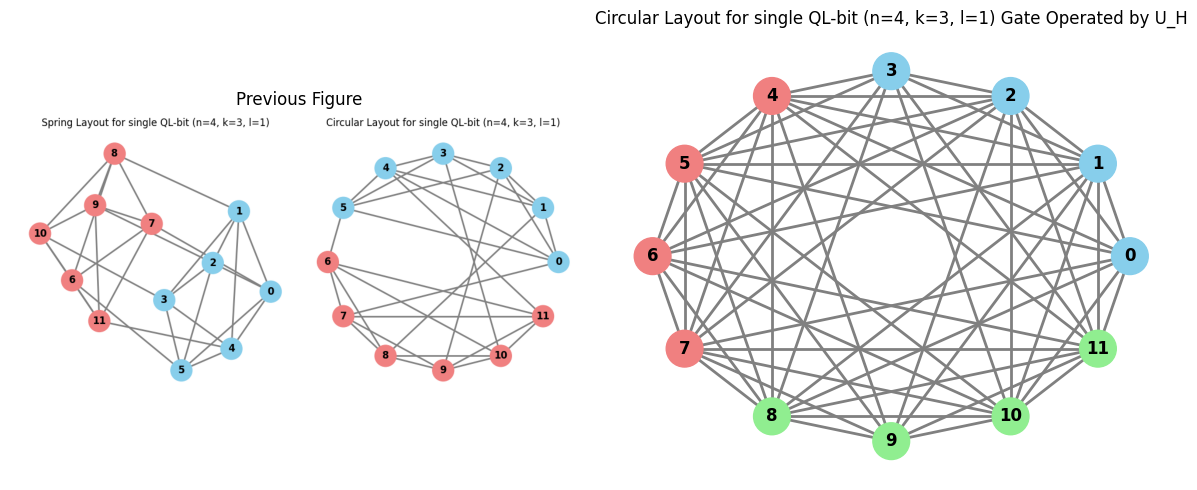

In [ ]:
graph = r_a_H
G = nx.from_numpy_array(graph)

num_nodes = G.number_of_nodes()
node_colors = []
color_palette = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'cyan']

for i in range(num_nodes):
    group = i // 4  # Integer division to get group number (0-3 -> 0, 4-7 -> 1, etc.)
    color_index = group % len(color_palette)  # Use modulo to cycle through colors if needed
    node_colors.append(color_palette[color_index])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Load and display the previous figure
img = mpimg.imread('cb_graph.png')
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Previous Figure')

# Draw the circular graph in the second subplot
pos = nx.circular_layout(G)
axes[1].set_title(f'Circular Layout for single QL-bit (n=4, k=3, l=1) Gate Operated by U_H')
nx.draw(G, pos=pos, ax=axes[1], with_labels=True,
        node_color=node_colors,
        node_size=700,
        edge_color='gray', width=2,
        font_size=12, font_weight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

----------------
----------------

## TWO QL BITS

In [29]:
r_cb_dim = 2 * len(r_a)
r_cb = np.zeros([r_cb_dim, r_cb_dim])

In [30]:
# Define common dimensions
q = r_cb_dim // 4
h_a = len(r_a) // 2

# Extract quadrants from r_a and r_b
a_1 = r_a[:h_a, :h_a]  # top-left
c_a = r_a[:h_a, h_a:]  # top-right
c_a_T = r_a[h_a:, :h_a]  # bottom-left
a_2 = r_a[h_a:, h_a:]  # bottom-right

b_1 = r_b[:h_a, :h_a]  # top-left
c_b = r_b[:h_a, h_a:]  # top-right
c_b_T = r_b[h_a:, :h_a]  # bottom-left
b_2 = r_b[h_a:, h_a:]  # bottom-right

# Diagonal blocks 
r_cb[0:q, 0:q] = a_1 + b_1
r_cb[q:2*q, q:2*q] = a_1 + b_2
r_cb[2*q:3*q, 2*q:3*q] = a_2 + b_1
r_cb[3*q:, 3*q:] = a_2 + b_2

# Off-diagonal blocks
r_cb[0:q, q:2*q] = c_b  # block (0,1)
r_cb[q:2*q, 0:q] = c_b_T  # block (1,0)

r_cb[0:q, 2*q:3*q] = c_a  # block (0,2)
r_cb[q:2*q, 3*q:] = c_a  # block (1,3)

r_cb[2*q:3*q, 0:q] = c_a_T  # block (2,0)
r_cb[3*q:, q:2*q] = c_a_T  # block (3,1)

r_cb[2*q:3*q, 3*q:] = c_b  # block (2,3)
r_cb[3*q:, 2*q:3*q] = c_b_T  # block (3,2)

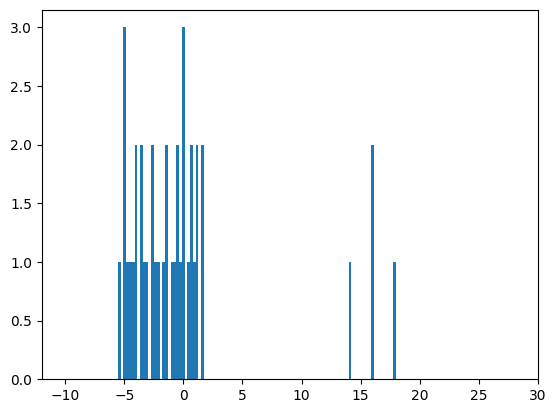

In [31]:
# Compute eigenvalues and eigenvectors
eigenvalues_cart, eigenvectors_cart = np.linalg.eigh(r_cb)

# Sort by eigenvalue magnitude
idx = np.abs(eigenvalues_cart).argsort()[::-1]
eigenvalues_cart = eigenvalues_cart[idx]
eigenvectors_cart = eigenvectors_cart[:, idx]

plt.hist(eigenvalues_cart, bins=100)  # histogram with 100 bins
plt.xlim(-12, 30)  # eigenvalues between 0 and 2
plt.show()

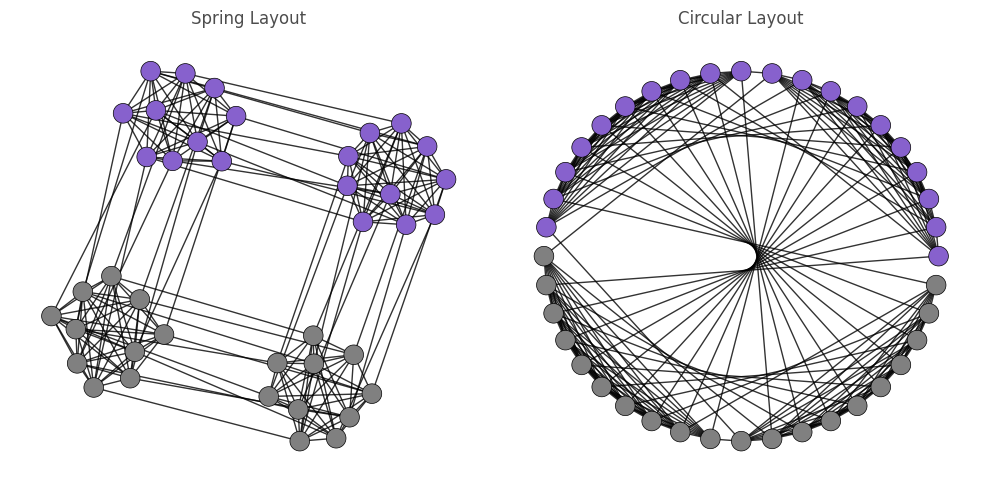

In [ ]:
suitable_pairs = []

In [369]:
suitable_pairs.append(group_colors)
print(suitable_pairs)

[['#315E7F', '#EA3368'], ['#E63380', '#85559B'], ['#E63380', '#3070AD'], ['#85559B', '#DCA237'], ['#8761CD', '#808080'], ['#EA33AD', '#78AA61'], ['#85559B', '#EA3368'], ['#8761CD', '#808080']]


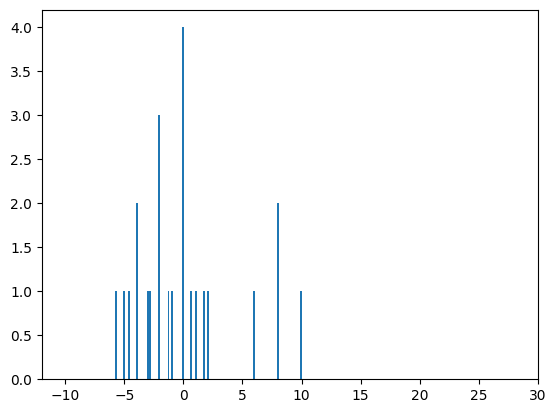

In [ ]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(r_cb)

# Sort by eigenvalue magnitude
idx = np.abs(eigenvalues).argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

plt.hist(eigenvalues, bins=100)  # histogram with 100 bins
plt.xlim(-12, 30)  # eigenvalues between 0 and 2
plt.show()

In [ ]:
print(len(eigenvectors[0]))
eigenvectors[0]

dimension_spanned = np.linalg.matrix_rank(eigenvectors)

print(f"The dimension spanned by the eigenvectors is: {dimension_spanned}")
print(f"Total number of eigenvectors provided: {eigenvectors.shape[1]}")

24
The dimension spanned by the eigenvectors is: 24
Total number of eigenvectors provided: 24


----------------
----------------

## TWO QL BIT GATES

In [ ]:
U_I = np.eye(h_a)
U_Z = np.zeros((h_a, h_a))
U_X = np.zeros((h_a, h_a))
U_H = np.zeros((h_a, h_a))

In [ ]:
# Basic Pauli matrices (2x2)
pauli_I = np.eye(2)
pauli_X = np.array([[0, 1], [1, 0]])
pauli_Z = np.array([[1, 0], [0, -1]])
pauli_H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)


N = r_cb_dim // 2
# Since each block is 2x2
I_2 = np.eye(N)

# Two QL-bit gates (2*N)x(2*N) given by eqa (4.5a-d) in Quantum information with quantumlike bits
U_I_cb = np.kron(pauli_I, I_2)
U_X_cb = np.kron(pauli_Z, I_2)
U_Z_cb = np.kron(pauli_X, I_2)
U_H_cb = np.kron(pauli_H, I_2)

# CNOT
term_1 = pauli_I + pauli_X #pauli_X is Z in traditional QM gate methods
term_2 = pauli_I - pauli_X
half_pauli_X = np.kron(pauli_Z, np.eye(4))
U_CN_cb = 0.5 * np.kron(term_1, I_2) + 0.5 * np.kron(term_2,half_pauli_X)

#------------------------------------#
#------------------------------------#
# # Standard CNOT for 2 qubits (4x4)
# CNOT_standard = np.array([
#     [1, 0, 0, 0],
#     [0, 0, 0, 1],
#     [0, 0, 1, 0],
#     [0, 1, 0, 0]
# ])


# # Expand CNOT to include the additional 2D space for each qubit
# # This creates a 16x16 matrix
# U_CN = np.kron(CNOT_standard, np.kron(I_2, I_2))

ValueError: operands could not be broadcast together with shapes (24,24) (16,16) 

In [ ]:
r_cb_I = U_I_cb @ r_cb @ U_I_cb
r_cb_X = U_X_cb @ r_cb @ U_X_cb
r_cb_Z = U_Z_cb @ r_cb @ U_Z_cb
r_cb_H = U_H_cb @ r_cb @ U_H_cb
r_cb_CN = U_CN_cb @ r_cb @ U_CN_cb

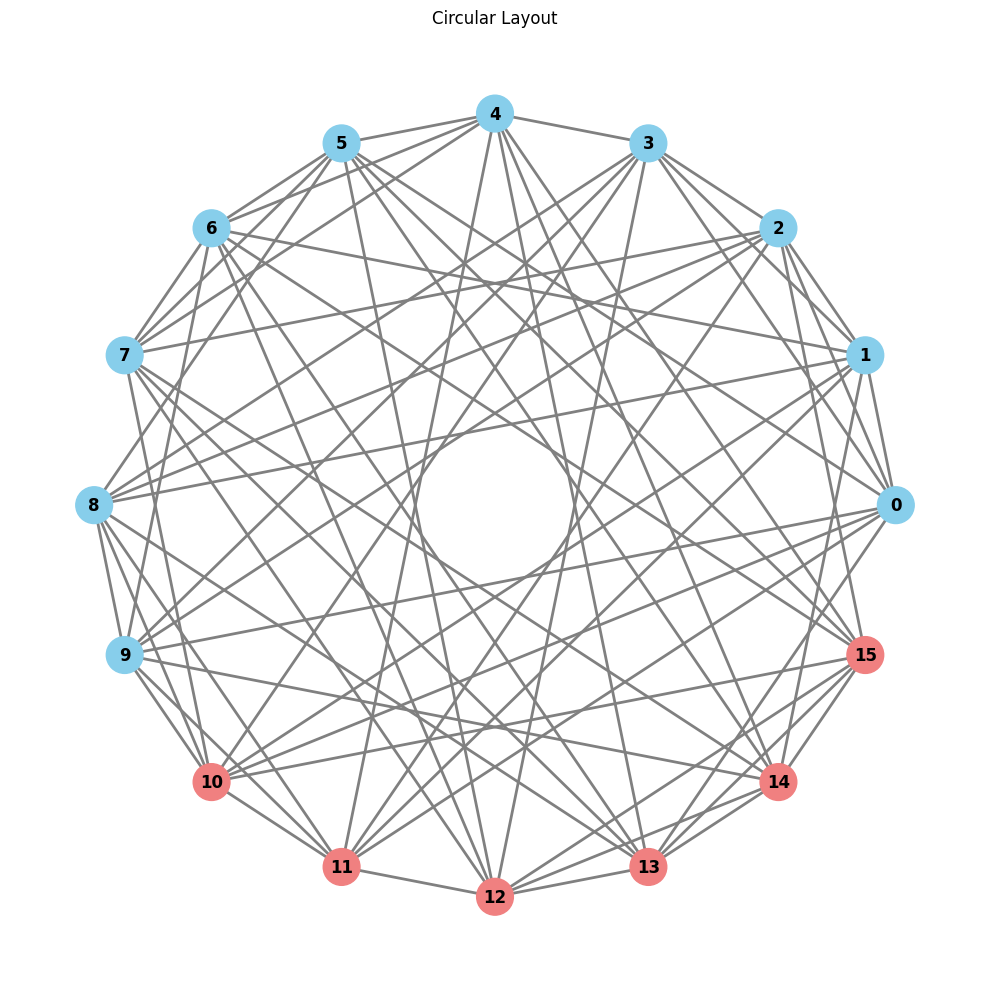

In [ ]:
G = nx.from_numpy_array(U_CN_cb @ U_H_cb @ r_cb @ U_CN_cb @ U_H_cb)

# Create color map for groups of 4 nodes
num_nodes = G.number_of_nodes()
node_colors = []
color_palette = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'cyan']

for i in range(num_nodes):
    group = i // 10  # Integer division to get group number (0-3 -> 0, 4-7 -> 1, etc.)
    color_index = group % len(color_palette)  # Use modulo to cycle through colors if needed
    node_colors.append(color_palette[color_index])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Different layout options
# layouts = {
#     'Spring': nx.spring_layout(G),
#     'Circular': nx.circular_layout(G),
# }

# for ax, (name, pos) in zip(axes.flat, layouts.items()):
#     ax.set_title(f'{name} Layout')
#     nx.draw(G, pos=pos, ax=ax, with_labels=True,
#             node_color=node_colors,  # Use the color list instead of single color
#             node_size=700,
#             edge_color='gray', width=2,
#             font_size=12, font_weight='bold')
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

# Plot directly onto the single axis 'ax'
pos = nx.circular_layout(G)

# Plot directly onto the single axis 'ax'
ax.set_title('Circular Layout')
nx.draw(G, pos=pos, ax=ax, with_labels=True,
        node_color=node_colors,  # Use the color list instead of single color
        node_size=700,
        edge_color='gray', width=2,
        font_size=12, font_weight='bold')
ax.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
### Methodically do an example of gates acting on computational state then do Hadamard, CNOT, then the combination

In [ ]:
r_cb_dim = 2 * len(r_a)
r_tilde = np.zeros([r_cb_dim, r_cb_dim])

In [ ]:
# Define common dimensions
q = r_cb_dim // 4
h_a = len(r_a) // 2

# Extract quadrants from r_a and r_b
a_1 = r_a[:h_a, :h_a]  # top-left
c_a = r_a[:h_a, h_a:]  # top-right
c_a_T = r_a[h_a:, :h_a]  # bottom-left
a_2 = r_a[h_a:, h_a:]  # bottom-right

b_1 = r_b[:h_a, :h_a]  # top-left
c_b = r_b[:h_a, h_a:]  # top-right
c_b_T = r_b[h_a:, :h_a]  # bottom-left
b_2 = r_b[h_a:, h_a:]  # bottom-right

# Diagonal blocks 
r_tilde[0:q, 0:q] = ((a_1 + a_2) / 2) + b_1 + ((c_a + c_a_T) / 2)  # block (0,0)
r_tilde[q:2*q, q:2*q] = ((a_1 + a_2) / 2) + b_2 - ((c_a + c_a_T) / 2)  # block (1,1)
r_tilde[2*q:3*q, 2*q:3*q] = ((a_1 + a_2) / 2) + b_1 - ((c_a + c_a_T) / 2)  # block (2,2)
r_tilde[3*q:, 3*q:] = ((a_1 + a_2) / 2) + b_2 + ((c_a + c_a_T) / 2)  # block (3,3)

# Off-diagonal blocks
# Upper-left
r_tilde[0:q, q:2*q] = 0  # block (0,1)
r_tilde[q:2*q, 0:q] = 0  # block (1,0)

# Upper-right
r_tilde[0:q, 3*q:] = c_b  # block (0,3)
r_tilde[q:2*q, 2*q:3*q] = c_b_T  # block (1,2)
r_tilde[0:q, 2*q:3*q] = ((a_1 - a_2) / 2) - ((c_a - c_a_T) / 2)  # block (0,2)
r_tilde[q:2*q, 3*q:] = ((a_1 - a_2) / 2) + ((c_a - c_a_T) / 2)  # block (1,3)

# Bottom-left
r_tilde[2*q:3*q, q:2*q] = c_b  # block (2,1)
r_tilde[3*q:, 0:q] = c_b_T  # block (3,0)
r_tilde[2*q:3*q, 0:q] = ((a_1 - a_2) / 2) + ((c_a - c_a_T) / 2)  # block (2,0)
r_tilde[3*q:, q:2*q] = ((a_1 - a_2) / 2) - ((c_a - c_a_T) / 2) # block (3,1)

# Bottom-right
r_tilde[2*q:3*q, 3*q:] = 0  # block (2,3)
r_tilde[3*q:, 2*q:3*q] = 0  # block (3,2)

/var/folders/kz/_z8xk68n3g5bxpxhzpg1180c0000gn/T/ipykernel_27336/4205534318.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu_r')


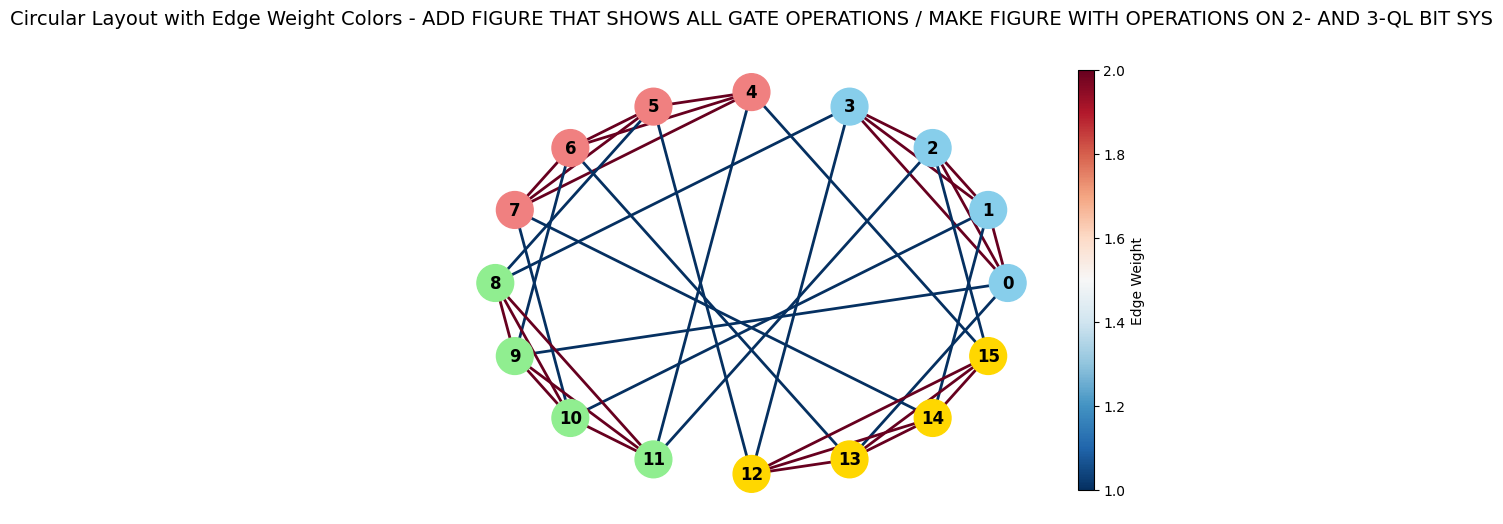

In [ ]:
adj_matrix = U_CN_cb  @ r_cb  @ U_CN_cb
G = nx.from_numpy_array(adj_matrix)

# Create color map for groups of 4 nodes
num_nodes = G.number_of_nodes()
node_colors = []
color_palette = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'cyan']

for i in range(num_nodes):
    group = i // 4  # Integer division to get group number (0-3 -> 0, 4-7 -> 1, etc.)
    color_index = group % len(color_palette)  # Use modulo to cycle through colors if needed
    node_colors.append(color_palette[color_index])

# Get edge weights for coloring
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# Normalize weights for color mapping
# Use a diverging colormap centered at 0
vmin = min(weights) if weights else 0
vmax = max(weights) if weights else 1
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# Use a diverging colormap: dark colors for negative, light for positive
# RdBu_r goes from dark red (negative) through white (zero) to dark blue (positive)
cmap = cm.get_cmap('RdBu_r')
edge_colors = [cmap(norm(weight)) for weight in weights]

# Create figure with space for colorbar
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use circular layout
pos = nx.circular_layout(G)

ax.set_title('Circular Layout with Edge Weight Colors - ADD FIGURE THAT SHOWS ALL GATE OPERATIONS / MAKE FIGURE WITH OPERATIONS ON 2- AND 3-QL BIT SYS', fontsize=14, pad=20)

# Draw the graph with colored edges
nx.draw(G, pos=pos, ax=ax, with_labels=True,
        node_color=node_colors,
        node_size=700,
        edge_color=edge_colors,  # Use the computed edge colors
        width=2,
        font_size=12, 
        font_weight='bold',
        edge_cmap=cmap,
        edge_vmin=vmin,
        edge_vmax=vmax)
ax.axis('off')

# Add a colorbar to the right of the plot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(sm, cax=cbar_ax, label='Edge Weight')

plt.subplots_adjust(right=0.9)  # Make room for the colorbar


plt.show()